## Exploratory Data Analysis (EDA) – Phase 2

This notebook presents the exploratory data analysis (EDA) conducted in Phase 2 of the
*MTH2526 – Data Mining for Cybersecurity* project.

The primary goal of this analysis is to understand the structure, distribution, and
characteristics of the cybersecurity dataset, identify class imbalance and potential
anomalies, and prepare insights that will guide feature engineering and data mining
techniques applied in later stages.



## Dataset Loading and Initial Inspection

The dataset is loaded from a pre-cleaned CSV file to ensure consistency and to
avoid repeating earlier data cleaning steps.

In cybersecurity datasets, preprocessing is critical because raw data often
contains missing values, corrupted records, or inconsistent formats due to
packet loss, logging errors, or sensor issues.

Printing the dataset shape provides an immediate overview of the number of
samples and features, which is especially important when working with
large-scale network traffic or intrusion detection datasets.


In [1]:
import pandas as pd

df = pd.read_csv('../data/sample_data.csv', low_memory=False)

df.columns = df.columns.str.strip()

print(df.shape)


(500, 79)


### Attack Label Distribution

This section examines the distribution of attack labels within the dataset.
Label imbalance is a common challenge in cybersecurity classification tasks,
as benign traffic typically dominates real world network data.


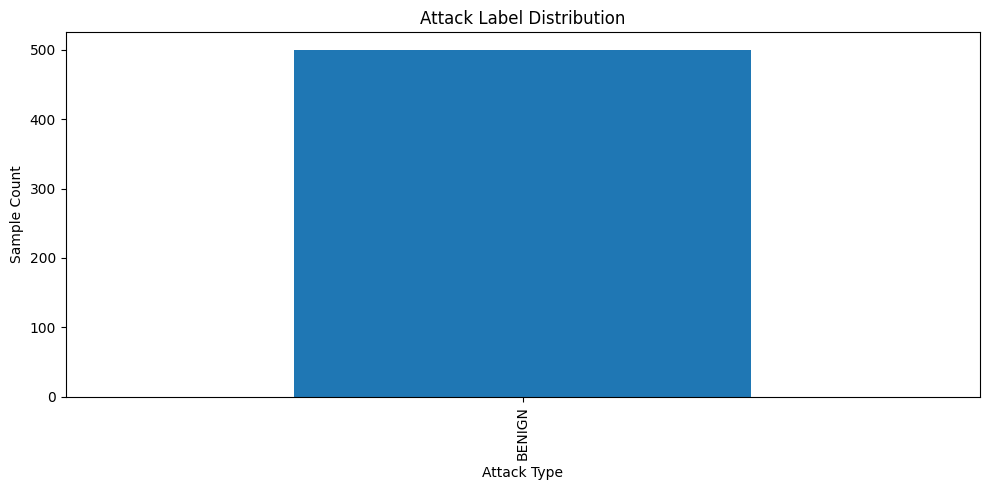

Label
BENIGN    500
Name: count, dtype: int64

In [2]:
import matplotlib.pyplot as plt

label_counts = df['Label'].value_counts()

plt.figure(figsize=(10, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Sample Count')
plt.tight_layout()
plt.show()

label_counts.head(10)


### Label Distribution Analysis

The visualization clearly shows a highly imbalanced dataset, where one class
dominates the majority of samples. This behavior is expected in cybersecurity
datasets, as normal network traffic significantly outweighs malicious activity.

Such imbalance must be carefully considered during model training and evaluation,
as traditional accuracy metrics may become misleading. Techniques such as class
weighting or resampling may be required in later stages.


### Dataset Sampling

Due to the large size of the dataset, a representative subset is sampled to
enable faster exploration and visualization.

Sampling is a practical approach in cybersecurity analysis, where datasets
often contain millions of records. A fixed random seed ensures reproducibility
of the analysis.


In [3]:
sample_size = min(5000, len(df))

sample_df = df.sample(sample_size, random_state=42)
plot_df = sample_df


### Sampling Analysis

The sampled subset preserves the overall structure and class distribution
of the original dataset while significantly reducing computational cost.

This enables faster experimentation without losing representative
cybersecurity traffic patterns.


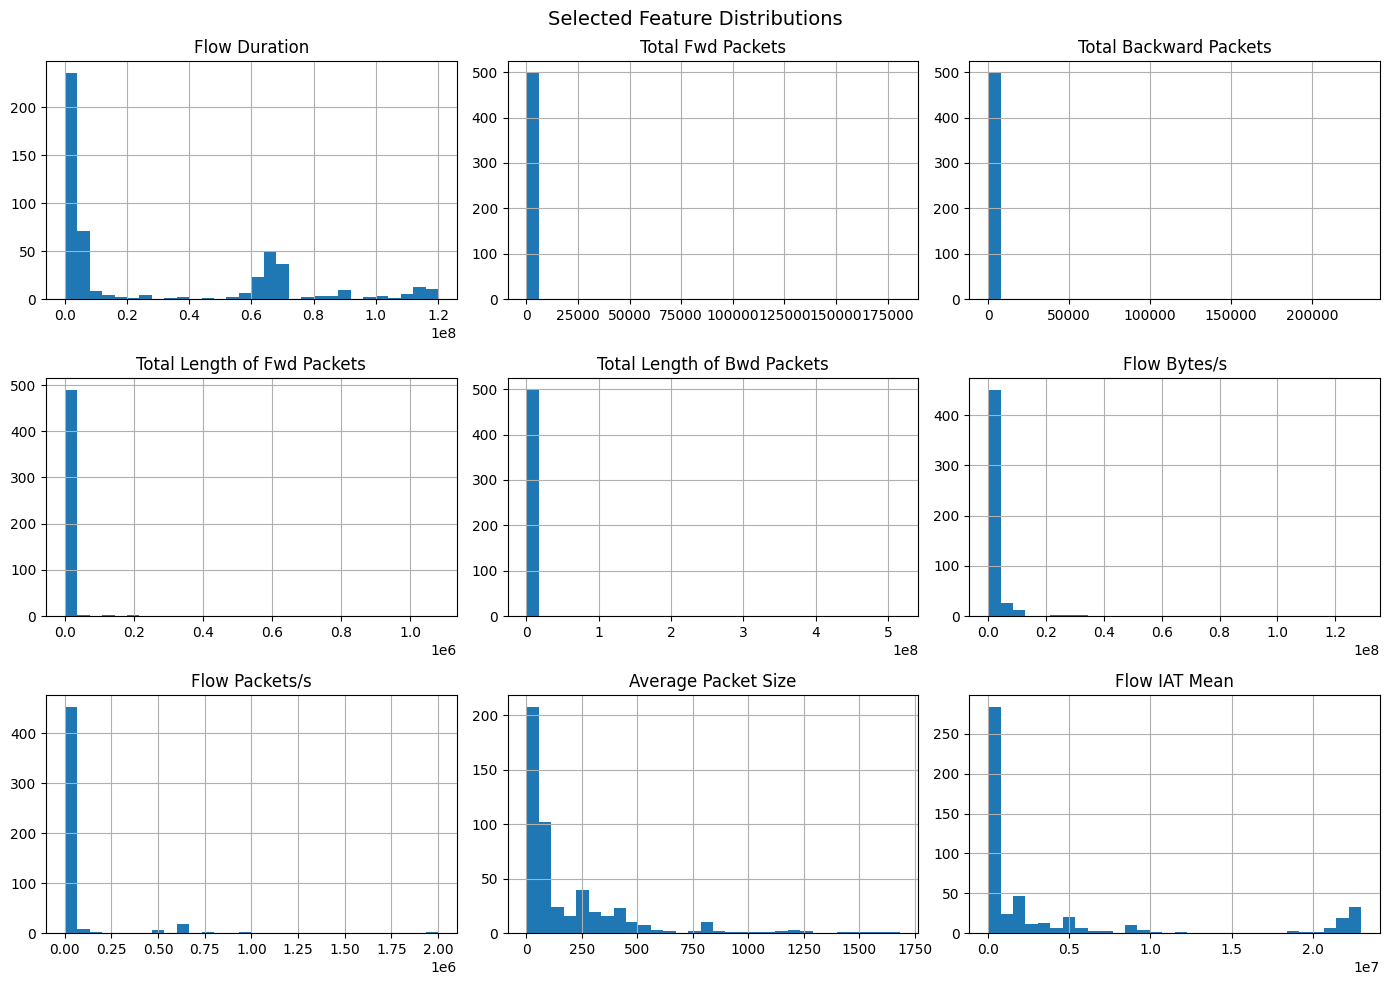

In [4]:
import matplotlib.pyplot as plt

selected_features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Total Length of Fwd Packets',
    'Total Length of Bwd Packets',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Average Packet Size',
    'Flow IAT Mean'
]

plot_df[selected_features].hist(figsize=(14, 10), bins=30)
plt.suptitle('Selected Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()



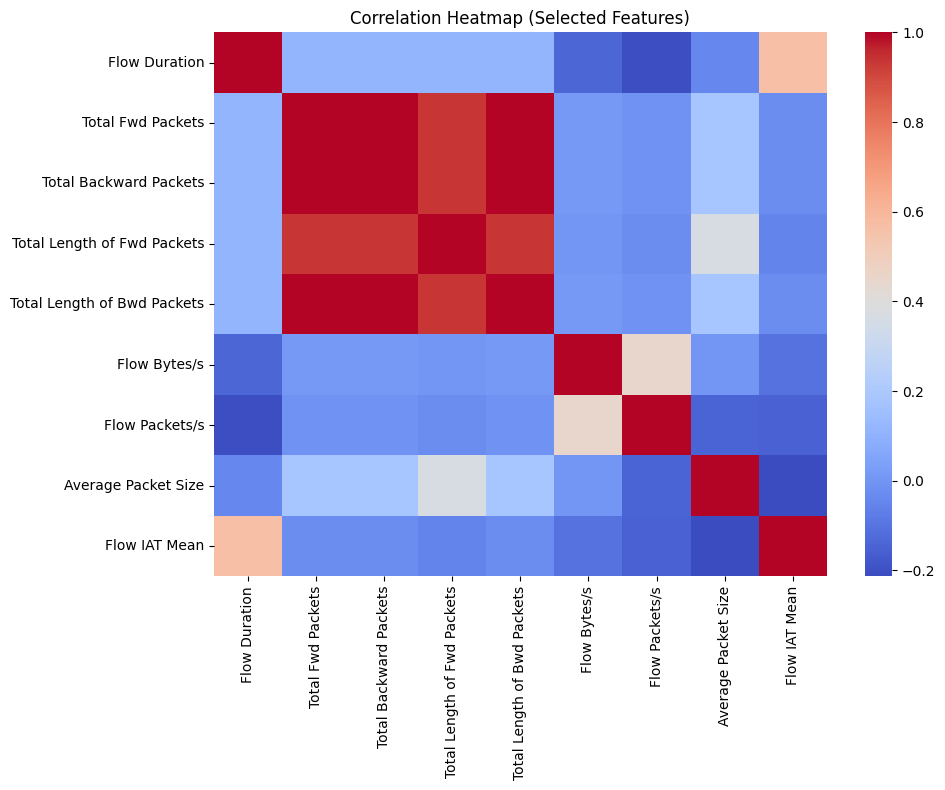

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = plot_df[selected_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap (Selected Features)")
plt.tight_layout()
plt.show()


### Role of EDA in Phase 2

Unlike Phase 1, which focused on initial data understanding and cleaning,
Phase 2 emphasizes deeper exploration of feature behavior and class distributions.

The insights obtained from this EDA directly influence feature selection,
data transformation decisions, and the choice of appropriate data mining
techniques for detecting cybersecurity threats.
